# Machine Failure Visualization Lab

## Dataset Selection & Context
For this assignment, the **Machine Failure Dataset** was selected because predictive maintenance is a critical application of modern industrial data science. This dataset contains continuous sensor readings (Rotational speed, Torque, Tool wear) alongside discrete categorical failure modes (TWF, HDF, PWF, OSF) and a binary target (Machine failure). 

It presents a perfect opportunity to apply all aspects of scientific visualization:
- It requires multi-variate analysis to uncover complex failure patterns across different operational modes.
- Overlapping distributions of non-failures and failures necessitate advanced styling (alpha transparency, custom markers).
- The continuous variables are ideal for 3D modeling and 2D KDE surface plots to explore feature density topologies.
- The severe class imbalance between failures and non-failures makes Effective Design (Edward Tufte's principles) absolutely crucial for accurate visual communication without distorting the data-ink ratio.


## 1. Matplotlib Fundamentals & 6. Lab Workflow
First, we establish the fundamental `pyplot` interface by importing `matplotlib.pyplot` and `numpy`. 
As part of the lab workflow, we load the dataset using `pd.read_csv()`, inspect it using `describe()`, and check for missing values using `isnull().sum()`.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Lab Workflow: Load the dataset
data = pd.read_csv('machine_failure_cleaned.csv')

# Inspect data
print("Dataset Summary Statistics:")
display(data.describe())
print("\nMissing Values in Dataset:")
print(data.isnull().sum())


Dataset Summary Statistics:


,Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,Machine failure
count,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000
mean,1526.383393,40.330015,107.913602,0.004483,0.011717,0.004483,0.009577,0.029139
std,147.306781,9.420254,63.626881,0.066808,0.107613,0.066808,0.097398,0.168205
min,1168.000000,16.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1422.000000,33.600000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1501.000000,40.200000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1606.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2076.000000,68.900000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Missing Values in Dataset:
Rotational speed [rpm]    0
Torque [Nm]               0
Tool wear [min]           0
TWF                       0
HDF                       0
PWF                       0
OSF                       0
Machine failure           0
dtype: int64


## 2. Customization — Styling, Annotations & Legends
Here we demonstrate the fundamental Figure → Axes → Plot hierarchy.
We apply specific customizations:
- **Colors**: `#2196F3` (Non-Failure) and `#E53935` (Failure)
- **Styling**: Distinct marker shapes (`o` and `x`), `alpha=0.6` for overlapping clarity.
- **Annotations**: Pointing out the peak failure zone.
- **Legends**: `loc='upper right'`, `fancybox=True`, `shadow=True`.


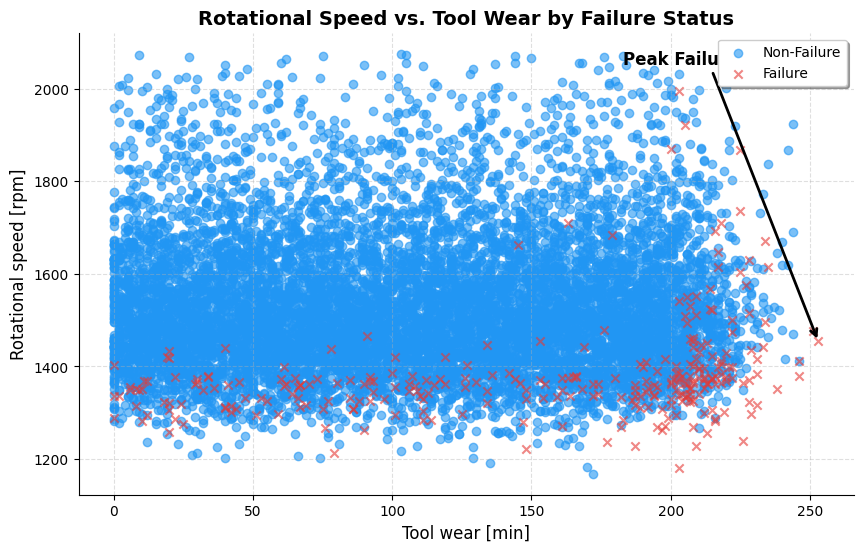

In [6]:
# Figure -> Axes setup
fig, ax = plt.subplots(figsize=(10, 6))

# Define strict hex color codes
color_non_fail = '#2196F3'
color_fail = '#E53935'

failures = data[data['Machine failure'] == 1]
non_failures = data[data['Machine failure'] == 0]

# Tufte principles applied: Color AND Shape differences (Accessibility)
ax.scatter(non_failures['Tool wear [min]'], non_failures['Rotational speed [rpm]'], 
           color=color_non_fail, marker='o', alpha=0.6, label='Non-Failure')
ax.scatter(failures['Tool wear [min]'], failures['Rotational speed [rpm]'], 
           color=color_fail, marker='x', alpha=0.6, label='Failure')

# Annotations: Peak failure zone on tool wear
peak_wear = failures['Tool wear [min]'].max()
peak_speed = failures[failures['Tool wear [min]'] == peak_wear]['Rotational speed [rpm]'].values[0]

ax.annotate('Peak Failure Zone', xy=(peak_wear, peak_speed), 
            xytext=(peak_wear - 70, peak_speed + 600),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=2),
            fontsize=12, fontweight='bold')

# Hierarchy components
plt.title("Rotational Speed vs. Tool Wear by Failure Status", fontsize=14, fontweight='bold')
plt.xlabel("Tool wear [min]", fontsize=12)
plt.ylabel("Rotational speed [rpm]", fontsize=12)

# Tufte's data-ink ratio principles: Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Minimize gridlines
ax.grid(True, linestyle='--', alpha=0.4)

# Custom legend
ax.legend(loc='upper right', fancybox=True, shadow=True)

# Lab: Export high-resolution output
plt.savefig('fundamental_plot.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fundamental_plot.svg', format='svg', bbox_inches='tight')

plt.show()


### Visualization Caption: Fundamental Scatter Plot
**What it shows:** This scatter plot illustrates the relationship between Tool Wear and Rotational Speed, distinctly coloring non-failures (blue) and failures (red). The annotation points directly to the peak tool wear zone where failures cluster.
**Why it matters:** It reveals that while non-failures and failures overlap significantly at lower tool wear limits, machine failures become highly concentrated and almost inevitable at the extreme upper bounds of tool wear. This highlights the necessity of threshold-based alerts to prevent unexpected downtime.


## 3. Multi-Plot Visualization & Layouts
We construct a master multi-panel figure in a 2x3 grid layout using `plt.subplots()` and `GridSpec`.
The scatter plot dynamically spans two columns, and the design strictly adheres to Tufte's Gestalt and data-ink principles.


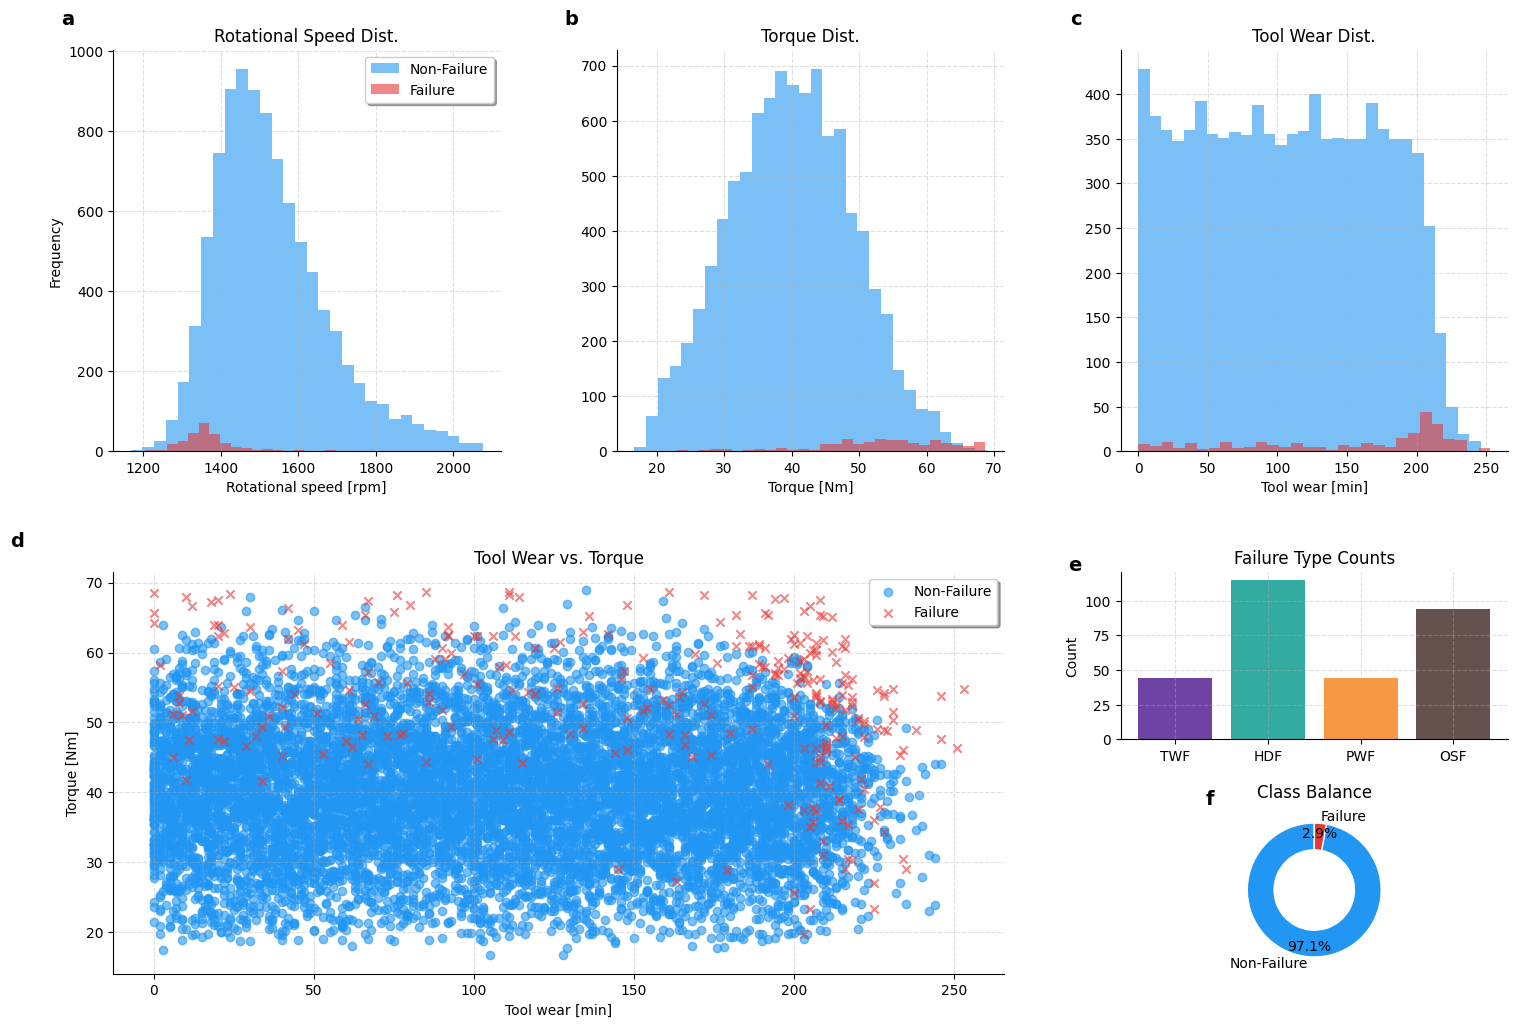

In [7]:
fig = plt.figure(figsize=(18, 12))

# 2x3 grid layout
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Row 0: Three Histograms
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1]) 
ax_c = fig.add_subplot(gs[0, 2])

# Row 1: Scatter spanning 2 columns
ax_d = fig.add_subplot(gs[1, 0:2])

# We use a nested GridSpec for the remaining slot to fit the Bar and Donut chart
gs_sub = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, 2], hspace=0.4)
ax_e = fig.add_subplot(gs_sub[0, 0])
ax_f = fig.add_subplot(gs_sub[1, 0])

axes = [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]
letters = ['a', 'b', 'c', 'd', 'e', 'f']

# Tufte principles across all subplots
for i, ax in enumerate(axes):
    if ax != ax_f: # Donut chart does not need grid/spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.4)
    # Subplot letter annotation in top-left
    ax.text(-0.1, 1.1, letters[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# a) Histogram: Rotational speed (Synchronized X not appropriate across different variables, but grouped visually)
ax_a.hist(non_failures['Rotational speed [rpm]'], bins=30, alpha=0.6, color=color_non_fail, label='Non-Failure')
ax_a.hist(failures['Rotational speed [rpm]'], bins=30, alpha=0.6, color=color_fail, label='Failure')
ax_a.set_title('Rotational Speed Dist.')
ax_a.set_xlabel('Rotational speed [rpm]')
ax_a.set_ylabel('Frequency')

# b) Histogram: Torque
ax_b.hist(non_failures['Torque [Nm]'], bins=30, alpha=0.6, color=color_non_fail)
ax_b.hist(failures['Torque [Nm]'], bins=30, alpha=0.6, color=color_fail)
ax_b.set_title('Torque Dist.')
ax_b.set_xlabel('Torque [Nm]')

# c) Histogram: Tool wear
ax_c.hist(non_failures['Tool wear [min]'], bins=30, alpha=0.6, color=color_non_fail)
ax_c.hist(failures['Tool wear [min]'], bins=30, alpha=0.6, color=color_fail)
ax_c.set_title('Tool Wear Dist.')
ax_c.set_xlabel('Tool wear [min]')
ax_a.legend(loc='upper right', fancybox=True, shadow=True)

# d) Scatter Plot: Tool wear vs Torque
ax_d.scatter(non_failures['Tool wear [min]'], non_failures['Torque [Nm]'], 
             color=color_non_fail, alpha=0.6, marker='o', label='Non-Failure')
ax_d.scatter(failures['Tool wear [min]'], failures['Torque [Nm]'], 
             color=color_fail, alpha=0.6, marker='x', label='Failure')
ax_d.set_title('Tool Wear vs. Torque')
ax_d.set_xlabel('Tool wear [min]')
ax_d.set_ylabel('Torque [Nm]')
ax_d.legend(loc='upper right', fancybox=True, shadow=True)

# e) Bar chart: Failure type counts (Using max 6 hues principle)
fail_counts = data[['TWF', 'HDF', 'PWF', 'OSF']].sum()
bar_colors = ['#4A148C', '#009688', '#F57F17', '#3E2723']
ax_e.bar(fail_counts.index, fail_counts.values, color=bar_colors, alpha=0.8)
ax_e.set_title('Failure Type Counts')
ax_e.set_ylabel('Count')

# f) Donut chart: Class balance
class_counts = data['Machine failure'].value_counts()
wedges, texts, autotexts = ax_f.pie(class_counts, labels=['Non-Failure', 'Failure'], 
                                    colors=[color_non_fail, color_fail], 
                                    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
                                    wedgeprops=dict(width=0.4, edgecolor='w'))
ax_f.set_title('Class Balance')

plt.tight_layout()
plt.savefig('master_multi_panel.pdf', dpi=300, bbox_inches='tight')
plt.savefig('master_multi_panel.svg', format='svg', bbox_inches='tight')
plt.show()


### Visualization Caption: Multi-Panel Distribution & Layout
**What it shows:** A comprehensive 6-panel grid analyzing feature distributions and class balances. It features histograms comparing failure/non-failure frequencies across Speed, Torque, and Wear; a scatter plot of Tool Wear vs. Torque; a bar chart detailing the exact failure type counts (TWF, HDF, PWF, OSF); and a donut chart displaying the extreme class imbalance of the dataset.
**Why it matters:** This master layout is crucial for exploratory data analysis (EDA). It allows us to instantly identify which features exhibit differing distributions for failures (e.g., Torque shows distinct secondary peaks for failures), and structurally emphasizes the stark imbalance (~3% failures) which must be factored into any future predictive modeling.


## 4. 3D Plotting
Exploring feature relationships mathematically through 3-dimensional mapping. We use `viridis` and `plasma` colormaps to ensure strong visibility and effective gradient tracking without relying on visually problematic rainbow palettes.


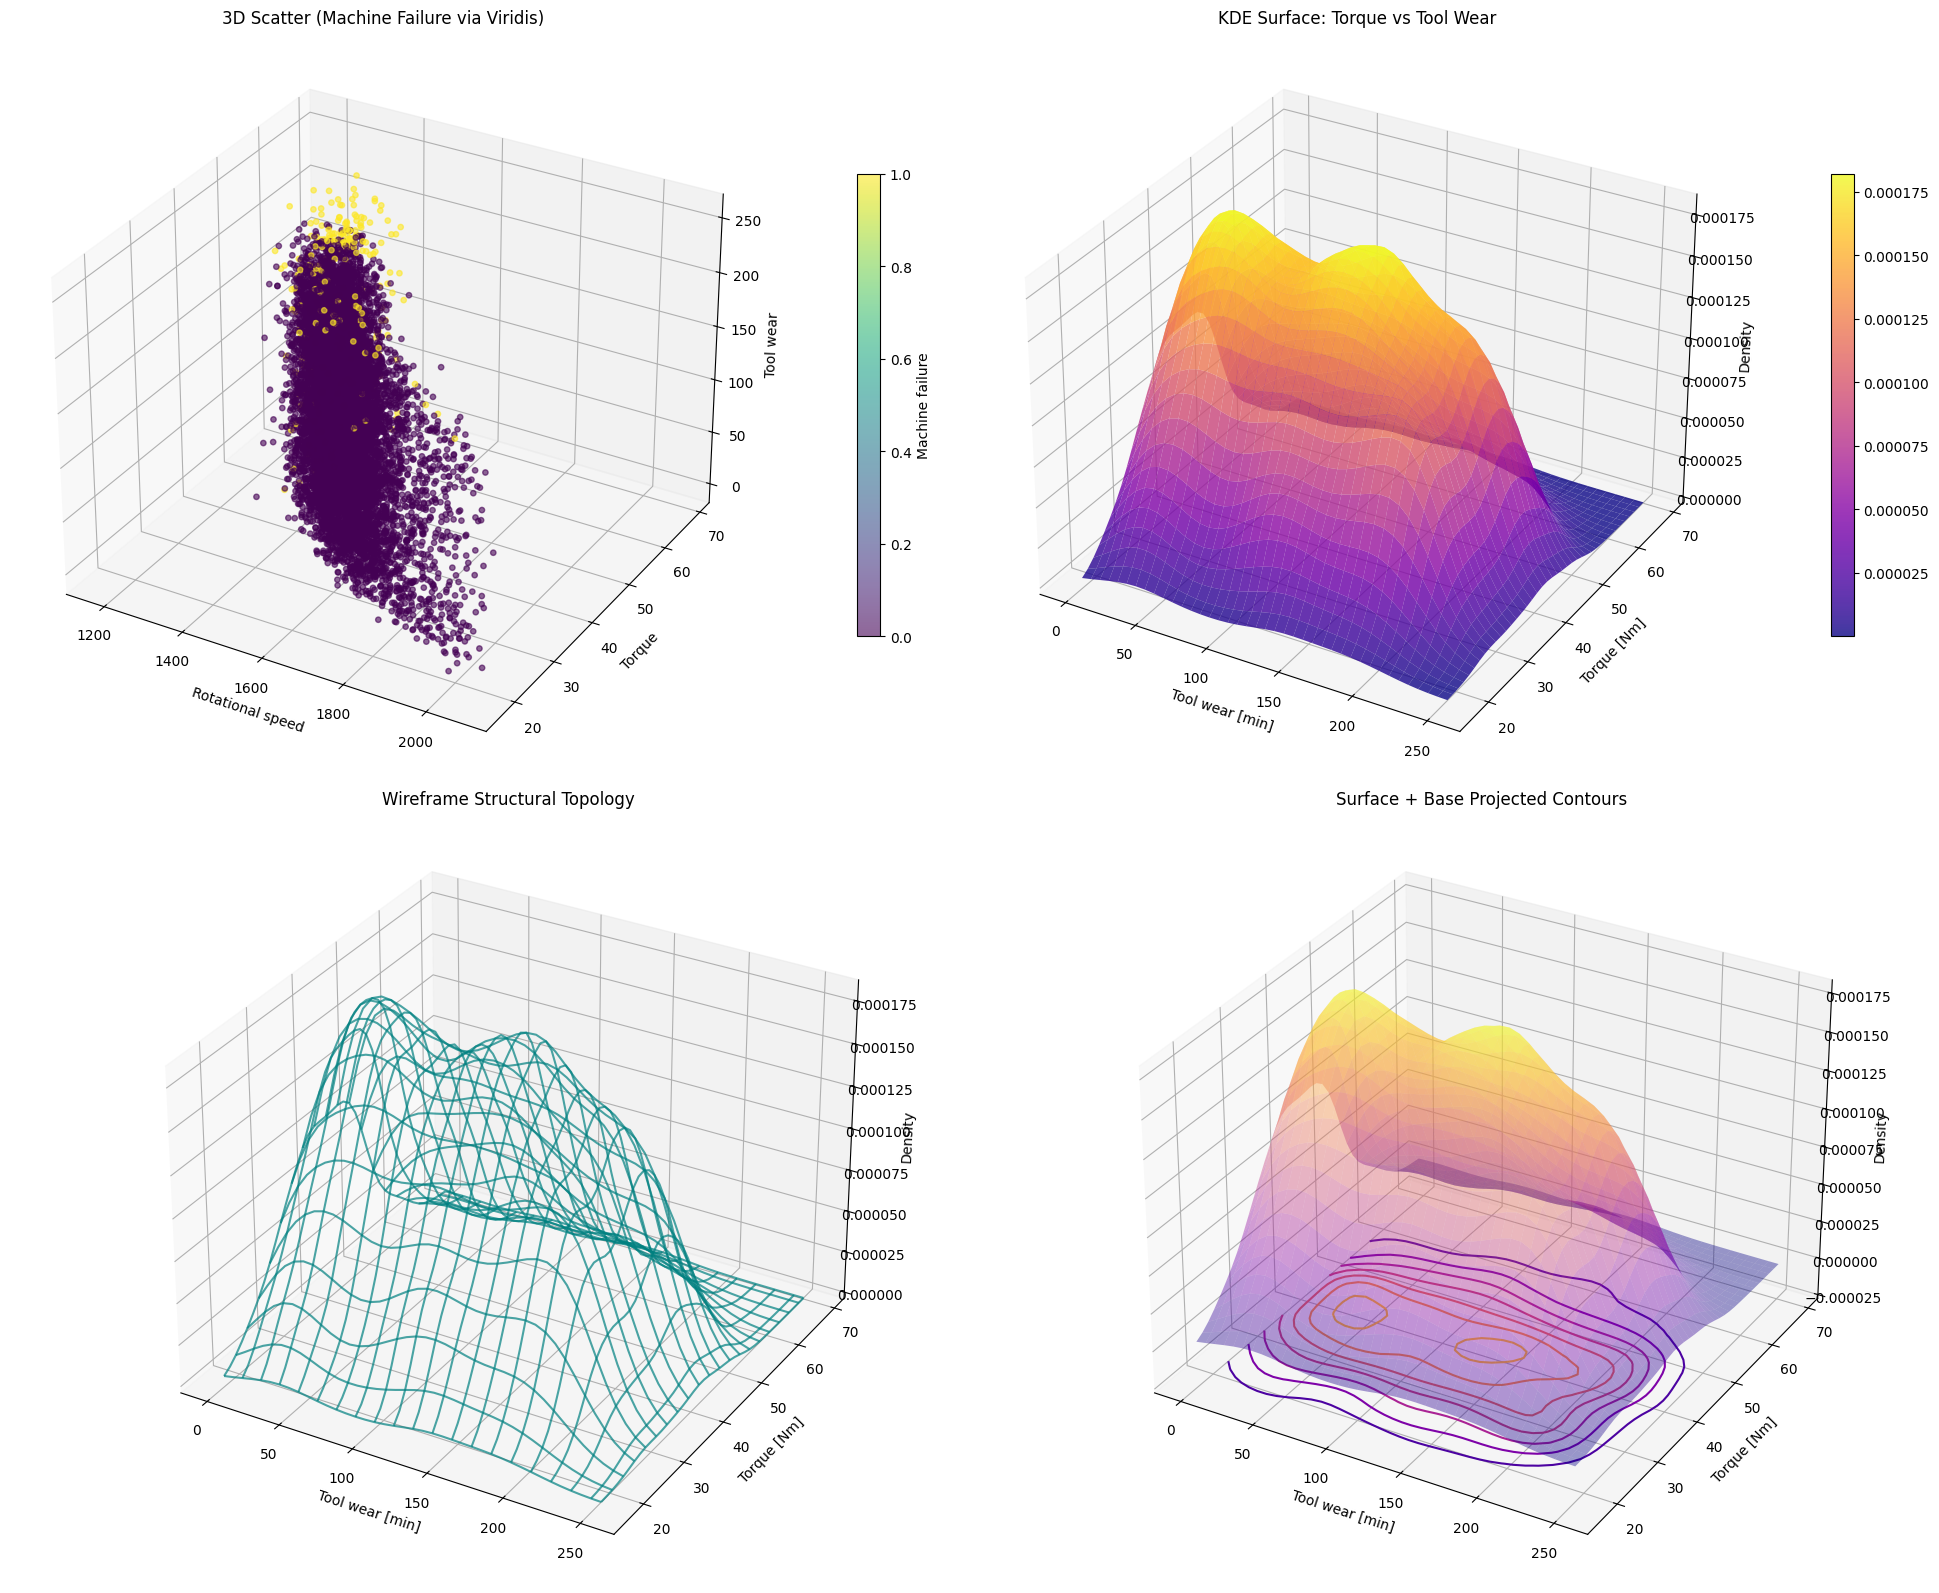

In [8]:
fig = plt.figure(figsize=(20, 16))

# A) 3D Scatter Plot (Color as 4th Dimension)
ax1 = fig.add_subplot(221, projection='3d')
sc = ax1.scatter(data['Rotational speed [rpm]'], data['Torque [Nm]'], data['Tool wear [min]'],
                 c=data['Machine failure'], cmap='viridis', alpha=0.6, s=15, marker='o')
ax1.set_xlabel('Rotational speed')
ax1.set_ylabel('Torque')
ax1.set_zlabel('Tool wear')
ax1.set_title('3D Scatter (Machine Failure via Viridis)')
cbar = fig.colorbar(sc, ax=ax1, pad=0.1, shrink=0.6)
cbar.set_label('Machine failure')

# Compute 2D KDE for Torque vs Tool wear
x = data['Tool wear [min]']
y = data['Torque [Nm]']

# Subsample for computational efficiency on the KDE surface
np.random.seed(42)
sample_idx = np.random.choice(len(data), min(1500, len(data)), replace=False)
x_sample = x.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.mgrid[xmin:xmax:40j, ymin:ymax:40j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([x_sample, y_sample])
kernel = gaussian_kde(values)
Z = np.reshape(kernel(positions).T, X.shape)

# B) 3D Surface Plot
ax2 = fig.add_subplot(222, projection='3d')
surf = ax2.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8, edgecolor='none')
ax2.set_xlabel('Tool wear [min]')
ax2.set_ylabel('Torque [Nm]')
ax2.set_zlabel('Density')
ax2.set_title('KDE Surface: Torque vs Tool Wear')
fig.colorbar(surf, ax=ax2, pad=0.1, shrink=0.6)

# C) 3D Wireframe Plot
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_wireframe(X, Y, Z, color='teal', alpha=0.7, rstride=2, cstride=2)
ax3.set_xlabel('Tool wear [min]')
ax3.set_ylabel('Torque [Nm]')
ax3.set_zlabel('Density')
ax3.set_title('Wireframe Structural Topology')

# D) 3D Contour Plot (Projected)
ax4 = fig.add_subplot(224, projection='3d')
# Combine surface and projected contour
ax4.plot_surface(X, Y, Z, cmap='plasma', alpha=0.4, edgecolor='none')
ax4.contour(X, Y, Z, zdir='z', offset=-np.max(Z)*0.15, cmap='plasma')
ax4.set_zlim(-np.max(Z)*0.15, np.max(Z))
ax4.set_xlabel('Tool wear [min]')
ax4.set_ylabel('Torque [Nm]')
ax4.set_zlabel('Density')
ax4.set_title('Surface + Base Projected Contours')

plt.tight_layout()
plt.savefig('3d_advanced_plots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('3d_advanced_plots.svg', format='svg', bbox_inches='tight')
plt.show()


### Visualization Caption: 3D Feature Topologies
**What it shows:** These 3D plots map out feature density and clustering. The scatter plot introduces Failure as a 4th dimension (via the Viridis colormap). The subsequent plots (Surface, Wireframe, and Projected Contour) display the computed 2D Kernel Density Estimate (KDE) of Torque vs. Tool Wear, effectively creating a "topological map" of where the machine operates most frequently.
**Why it matters:** The 3D KDE surfaces allow us to visualize continuous probability density rather than discrete data points, revealing the "safe operating valleys" and "high-risk peaks". This is essential for defining multi-variate operational boundaries in industrial systems, beyond simple 2D thresholds.
